# Exemplo do Cubo

In [12]:
!pip install gudhi
import numpy as np
import pandas as pd
import gudhi as gd
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
G = nx.generators.cubical_graph()

/tmp/ipykernel_738/3371271828.py:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


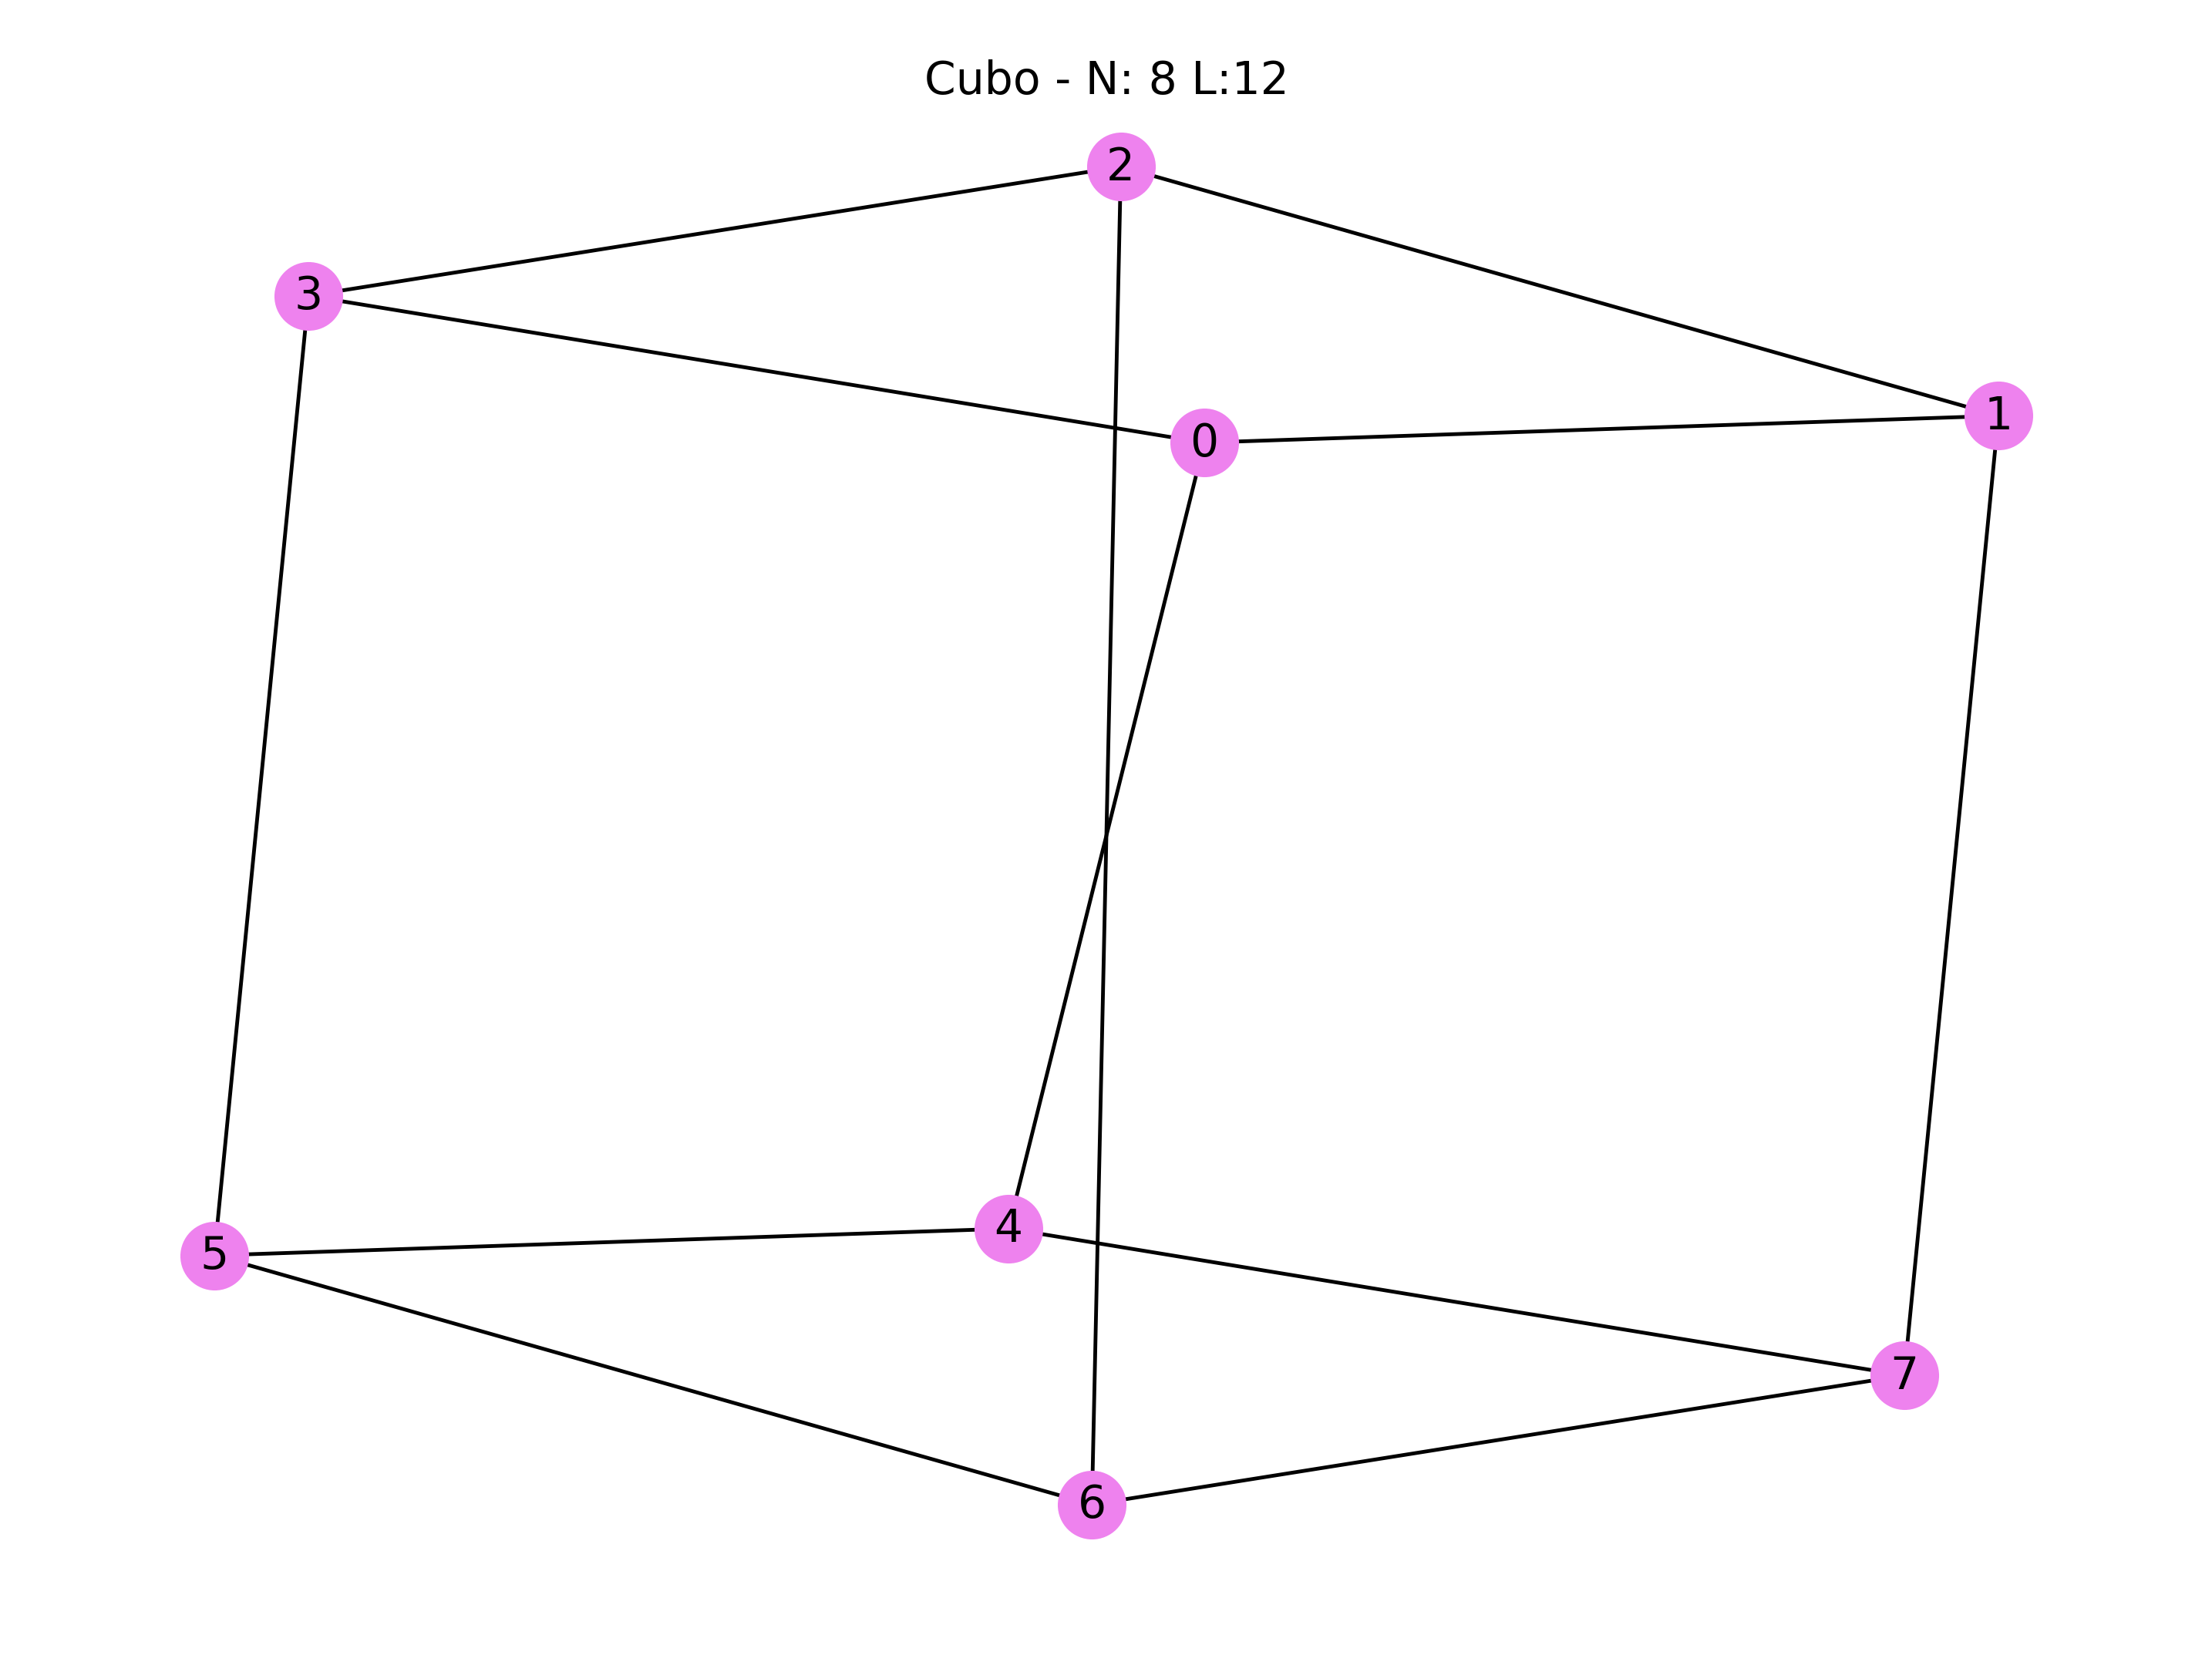

In [14]:
plt.figure(figsize=(8,6),dpi=350)
G.name='Cubo'
nx.draw_kamada_kawai(G,with_labels=True, node_color='violet')
plt.suptitle(G.name+' - N: '+str(G.number_of_nodes())+' L:'+str(G.number_of_edges()))
plt.tight_layout()
plt.show()

In [15]:
def persistantHomologyFromNetworkWithRips(G,name,dim,plot=True):
    dm=pd.DataFrame(dict(nx.shortest_path_length(G))).sort_index()
    dm=dm[sorted(dm.columns)]
    skeleton = gd.RipsComplex(distance_matrix = dm.values)

    Rips_simplex_tree = skeleton.create_simplex_tree(max_dimension = dim)

    BarCode = Rips_simplex_tree.persistence()

    #----Simplexes Resume
    simplexesLen={}
    for simplex,filtration in Rips_simplex_tree.get_filtration():
        if(len(simplex)-1 not in simplexesLen):
            simplexesLen[len(simplex)-1]=1
        else:
            simplexesLen[len(simplex)-1]+=1

    simplexesResume=''
    for item in simplexesLen.items():
        simplexesResume+=str(item[0])+': '+str(item[1])+' | '
    simplexesResume[0:-3]

    #----Barcode Resume
    dimensionsLen={}
    for dim in range(0,dim+1):
        dimensionsLen[dim]=len([bd for bd in BarCode if (bd[0]==dim)])

    dimensionResume=''
    for item in dimensionsLen.items():
        dimensionResume+=str(item[0])+': '+str(item[1])+' | '
    dimensionResume[0:-3]

    if plot:

        fig, ax = plt.subplots(1, 2, figsize=(10,4), dpi=250)

        gd.plot_persistence_barcode(BarCode, axes=ax[0])
        gd.plot_persistence_diagram(BarCode, axes=ax[1])

        ax[1].set_xlim(-0.1, 2.1)
        ax[1].set_ylim(-0.1, 2.1)

        plt.tight_layout()
        plt.show()

/usr/local/lib/python3.12/dist-packages/gudhi/persistence_graphical_tools.py:155: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


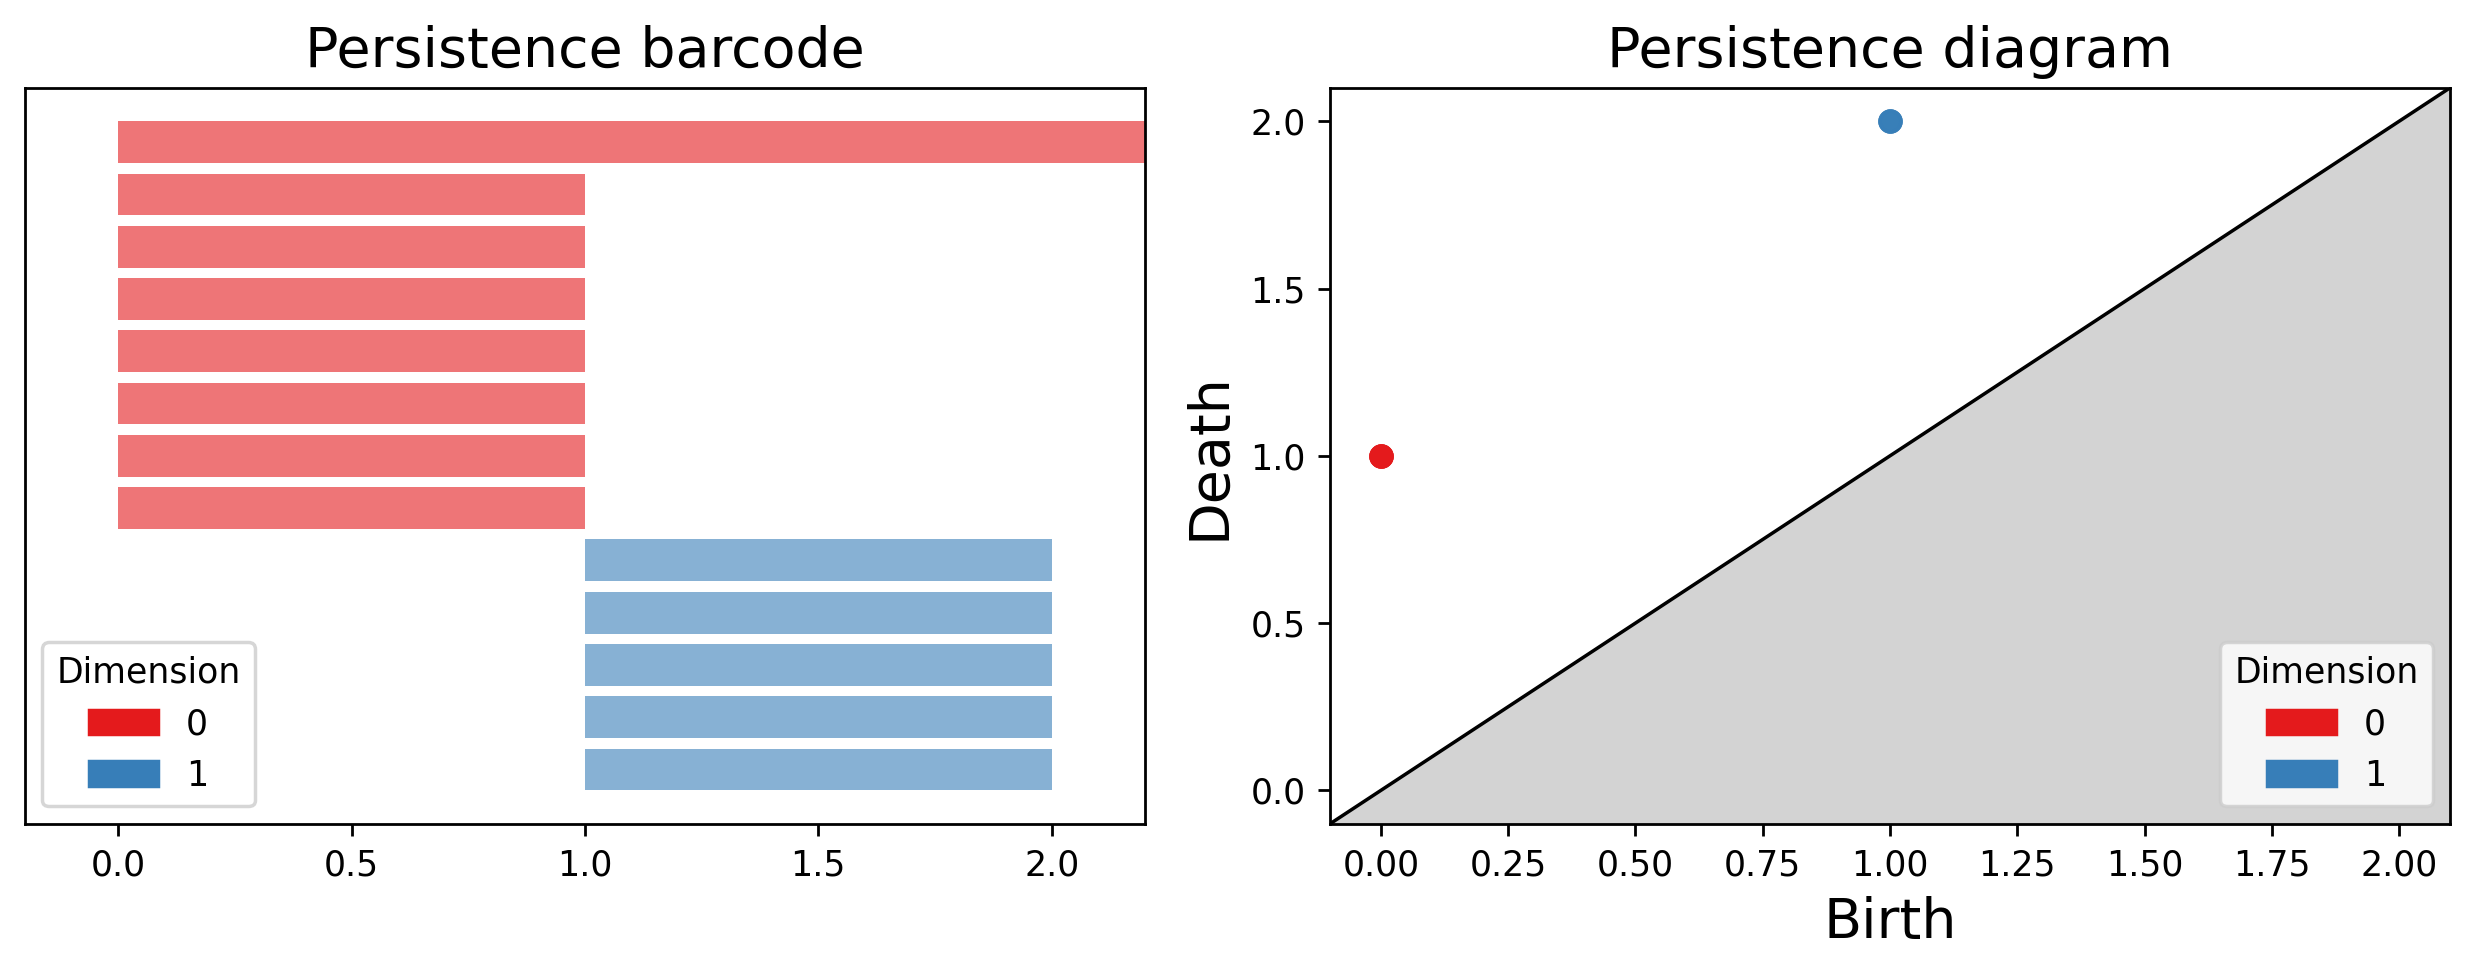

In [16]:
persistantHomologyFromNetworkWithRips(
    G,
    name="Cubo",
    dim=2,
    plot=True
)